# LAB-P8: El Modelo Neoclásico de Crecimiento Exógeno (Solow-Swan) (Julia)
- **ID de práctica:** LAB-P8-v1.0-julia
- **Capítulo del libro:** Cap. 9 — *An introduction to computational macroeconomics* (Bongers, Gómez y Torres, 2019)
- **Autores:** Dr. Antonio F. Romero Carrasco, Dra. Anelí Bongers
- **Fecha:** 2026-06-20
- **Versión:** 1.0
- **Licencia:** CC BY-SA 4.0 (este notebook) / MIT (el código de `MacroAIComp`)

Objetivo: Simular y analizar la dinámica de acumulación de capital en tiempo discreto, el proceso de transición hacia el estado estacionario, los efectos de perturbaciones estructurales (tasa de ahorro, demografía y TFP), y el principio de la Regla de Oro. Versión en Julia.


> **👋 BIENVENIDA A LA PRÁCTICA - LEER ANTES DE EMPEZAR**
> 
> *   **¿Nunca has usado Jupyter?** No te preocupes. Este cuaderno es interactivo. Haz clic en cualquier celda de código y pulsa **`Shift + Enter`** para ejecutarla. Ve de arriba a abajo en orden.
> *   **¿Se ha congelado o sale un asterisco `[*]` eterno?** Ve al menú superior y dale a `Kernel` ➔ `Restart`.
> *   **El objetivo** de esta práctica es que juegues con la economía. Cambia los números del código que representan impuestos, dinero o tecnología, vuelve a ejecutar y mira los gráficos. ¡No puedes romper nada!
>

### 🕹️ GUÍA RÁPIDA PARA DUMMIES - Modelo de Crecimiento de Solow-Swan
*   **¿Qué estamos haciendo aquí?** Analizando por qué crecen los países a largo plazo y cómo acumulan capital (maquinaria).
*   **La Regla de Oro:** Ahorrar más es bueno porque permite comprar más máquinas, pero si ahorras demasiado, no te queda dinero para consumir. Existe una "tasa de ahorro óptima" que maximiza el bienestar.
*   **¡Prueba esto!** Sube la tasa de ahorro y observa cómo la economía transiciona hacia un nivel de riqueza permanente más alto.


In [1]:
# En Google Colab se activarían y descargarían los paquetes necesarios.
# using Pkg; Pkg.activate("."); Pkg.instantiate()


In [2]:
using Pkg
Pkg.activate("../..")

using MacroAIComp
using Plots
using LinearAlgebra


  Activating project at `C:\Users\AntonioRC\Desktop\PIE`


## 1. El Marco Teórico: Crecimiento de Solow-Swan

El modelo de acumulación de capital per cápita se describe mediante:
$$k_{t+1} = \frac{(1 - \delta)k_t + s A_t k_t^\alpha}{1 + n}$$

Y las variables de bienestar en estado estacionario se derivan de:
$$\bar{k} = \left( \frac{\delta + n}{s A} \right)^{\frac{1}{\alpha - 1}}$$


In [3]:
params = default_calibration(SolowSwanParameters)
println(params)


SolowSwanParameters(0.35, 0.08, 0.2, 0.0, 1.0)


## 2. Equilibrio de Largo Plazo (Estado Estacionario)


In [4]:
ss = compute_solow_steady_state(params)

println("VALORES DE EQUILIBRIO DE LARGO PLAZO:")
println("  Capital per cápita (k*)     : ", ss["k"])
println("  Producción per cápita (y*)  : ", ss["y"])
println("  Consumo per cápita (c*)     : ", ss["c"])
println("  Inversión per cápita (i*)   : ", ss["i"])


VALORES DE EQUILIBRIO DE LARGO PLAZO:


  Capital per cápita (k*)     : 4.094636919540163
  Producción per cápita (y*)  : 1.6378547678160653
  Consumo per cápita (c*)     : 1.3102838142528523
  Inversión per cápita (i*)   : 0.3275709535632131


## 3. Verificación frente al oráculo

Comparamos contra los valores reportados en el libro y en `oraculo.md`: $k^* = 4.0946$, $c^* = 1.3103$.


In [5]:
@assert isapprox(ss["k"], 4.0946; atol=1e-4)
@assert isapprox(ss["c"], 1.3103; atol=1e-4)
println("OK: coincide con el oráculo.")


OK: coincide con el oráculo.


## 4. Análisis de Shock y Transición Dinámica

Simulamos un incremento en la tasa de ahorro del $20\%$ al $25\%$ en el período $t=5$ (índice 5 en Julia).


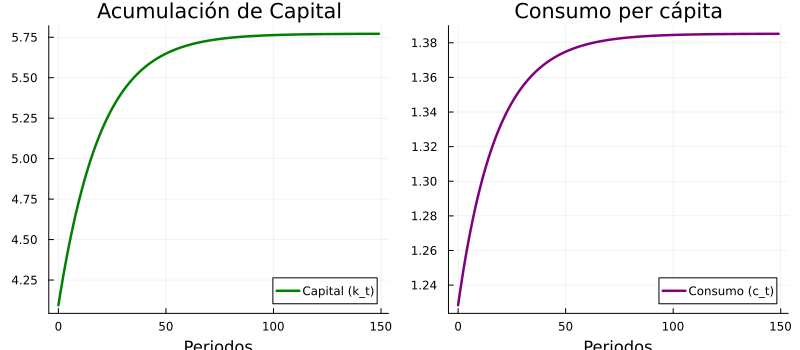

In [6]:
T = 150
s_path = fill(0.25, T)
n_path = fill(params.n, T)
A_path = fill(1.00, T)

res = simulate_solow_swan(params, ss["k"], s_path, n_path, A_path, T)

# Graficar
t = 0:(T-1)
p1 = plot(t, res["k"], label="Capital (k_t)", color=:green, lw=2.5)
title!("Acumulación de Capital")
xlabel!("Periodos")

p2 = plot(t, res["c"], label="Consumo (c_t)", color=:purple, lw=2.5)
title!("Consumo per cápita")
xlabel!("Periodos")

plot(p1, p2, layout=(1,2), size=(800, 350))


## 5. Demostración Visual de la Regla de Oro

El consumo de estado estacionario se maximiza cuando la tasa de ahorro equivale a la participación del capital en el PIB ($s = \alpha$).


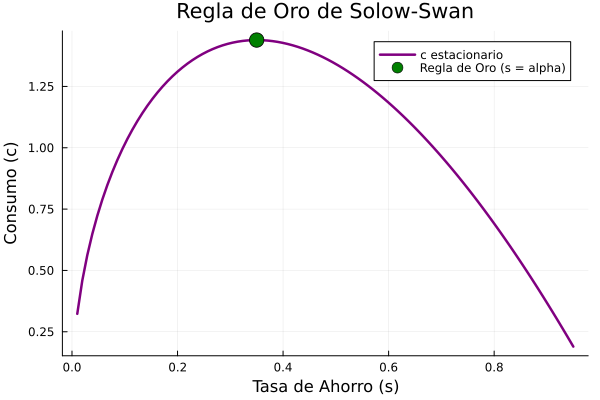

In [7]:
s_grid = range(0.01, 0.95, length=100)
c_ss_grid = [compute_solow_steady_state(params, s_val)["c"] for s_val in s_grid]

# Encontrar el óptimo (Regla de Oro)
alpha = params.alpha
ss_gold = compute_solow_steady_state(params, alpha)
c_gold = ss_gold["c"]

plot(s_grid, c_ss_grid, label="c estacionario", color=:purple, lw=2.5,
     title="Regla de Oro de Solow-Swan", xlabel="Tasa de Ahorro (s)", ylabel="Consumo (c)")
scatter!([alpha], [c_gold], label="Regla de Oro (s = alpha)", color=:green, markersize=8)


## 6. Simulación modular interactiva

Define una función para graficar la transición del capital ante shocks permanentes de ahorro o demografía.


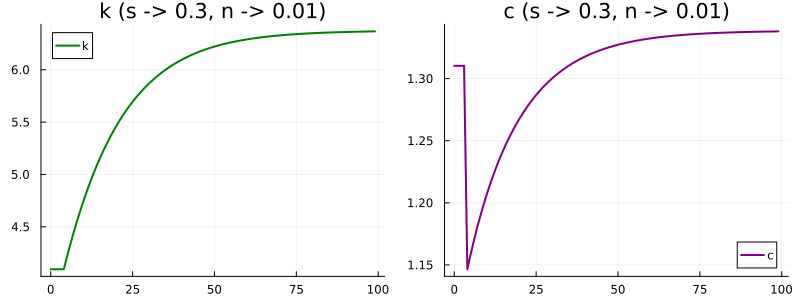

In [8]:
function graficar_solow_shocks(s_fn::Float64, n_fn::Float64)
    T_sh = 100
    s_p = fill(params.s, T_sh)
    n_p = fill(params.n, T_sh)
    A_p = fill(params.A, T_sh)
    
    s_p[5:end] .= s_fn
    n_p[5:end] .= n_fn
    
    res_sh = simulate_solow_swan(params, ss["k"], s_p, n_p, A_p, T_sh)
    
    p1 = plot(0:99, res_sh["k"], label="k", color=:green, lw=2)
    title!("k (s -> $s_fn, n -> $n_fn)")
    
    p2 = plot(0:99, res_sh["c"], label="c", color=:purple, lw=2)
    title!("c (s -> $s_fn, n -> $n_fn)")
    
    plot(p1, p2, layout=(1,2), size=(800, 300))
end

# Ejemplo de ejecución
graficar_solow_shocks(0.30, 0.01)


## 7. Buenas Prácticas Aplicadas y Conclusión

Este laboratorio demuestra cómo la ineficiencia dinámica puede producir sobreacumulación de capital, reduciendo el consumo a largo plazo. La regla de oro nos muestra la tasa de ahorro óptima que maximiza el consumo intertemporal.
